# Genetic Algorithm – Vermeer's *Girl with a Pearl Earring*

Approximate a target painting using **100 semi-transparent triangles** evolved by a Genetic Algorithm.

### Representation
Each individual is a flat list of **1 000 floats** (all in `[0, 1]`):  
100 triangles × 10 genes each → `[x1, y1, x2, y2, x3, y3, r, g, b, α]`

### Fitness
**Root Mean Squared Error (RMSE)** between the rendered image and the original — we **minimise** it.

### GA operators
| Component | Operator |
|-----------|----------|
| Selection | Tournament (size 3) |
| Crossover | One Point Crossover |
| Mutation  | Gaussian Mutation |

## 1. Setup

In [1]:
import numpy as np
from typing import Callable
from PIL import Image
import os
import random
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from time import time

genes_per_triangle = 10

Import from our library

* solution, triangle_solution and the data
* Selection: tournament
* Mutation: gaussian
* Crossover: one_point_crossover

In [2]:
from library.problem.solution import Solution
from library.problem.triangle_solution import TriangleSolution

from library.problem.fitness_sharing import apply_fitness_sharing
from library.algorithms.geneticalgorithms.selection import tournament_selection, rank_selection
from library.algorithms.geneticalgorithms.crossover import one_point_crossover, two_point_crossover
from library.algorithms.geneticalgorithms.mutation import gaussian_mutation, uniform_mutation

## 2. Load and display the target image

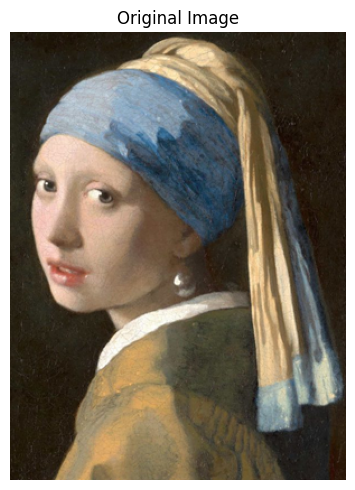

In [3]:
image_path = os.path.join('library', 'problem', 'data', 'girl_pearl_earing.png')

original_image = Image.open(image_path).convert('RGB')
original_image_array = np.array(original_image, dtype=np.uint8)

fig, ax = plt.subplots(figsize=(4, 5))
ax.imshow(original_image)
ax.axis('off')
ax.set_title('Original Image')
plt.tight_layout()
plt.show()

## 3. The First Genetic Algorithm

### Elitism

In [4]:
# We're going to create a function to get the best individual, which has the lowest fitness value so that we can apply elitism

def get_best_individual(population: list, minimization: bool = True):
    """
    Returns the best individual from the population based on fitness values.
    If minimization is True, it returns the individual with the lowest fitness value; otherwise, it returns the individual with the highest fitness value.

    Args:
        population (list): The population of individuals
        minimization (bool, optional): If True (the default), considers that lower values of fitness are better; otherwise, the opposite.
    """
    
    fitness_list = [ind.fitness() for ind in population]
    if minimization:
        return population[fitness_list.index(min(fitness_list)) ]
    else:
        return population[fitness_list.index(max(fitness_list)) ]

### Diversity

In [5]:
def compute_diversity(population):
    """
    Mean pairwise Euclidean distance between individuals, computed on per-gene-normalised genomes so that vertex, colour and alpha genes all contribute on a common [0, 1] scale.

    Each gene is divided by its natural range before the distance is computed:
        • x  → img_width
        • y  → img_height
        • r, g, b → 255
        • α  → 1   (already in [0, 1])

    This makes the diversity value independent of image size and of the relative magnitudes of the three gene families, so values are comparable across runs and across images.

    Parameters:
        population (list[TriangleSolution]): Current population. All individuals are assumed to have the same genome length and the same image dimensions.

    Returns:
        float: Mean Euclidean distance over all unordered pairs of normalised genomes.
    """
    W, H = population[0].img_width, population[0].img_height
    D = len(population[0].repr)

    # Per-gene divisor for one triangle, tiled across the whole genome.
    block_scale = np.array([W, H, W, H, W, H, 255.0, 255.0, 255.0, 1.0])
    scale = np.tile(block_scale, D // genes_per_triangle)

    reprs = np.asarray([ind.repr for ind in population], dtype=np.float64) / scale
    return float(pdist(reprs, metric='euclidean').mean())

### Genetic Algorithm

In [6]:
# Now let's create the genetic algorithm function
def genetic_algorithm(
    initial_population: list,
    max_generations: int,
    selection_algorithm: Callable,
    xo_method: Callable,
    mut_method: Callable,
    minimization: bool = True,
    xo_prob: float = 0.9,
    mut_prob: float = 0.1,
    elitism: bool = True,
    fitness_sharing: bool = False,
    sigma_share: float = 3.0,
    verbose: bool = False
):
    """
    Executes a genetic algorithm to optimize a population of individuals

    Args:
        initial_population (list): The starting population of individuals.
        max_generations (int): The maximum number of generations to evolve.
        selection_algorithm (Callable): Function used for selecting individuals.
        xo_method (Callable): Function for crossover between two individuals.
        mut_method (Callable): Function used for mutating an individual.
        minimization (bool, optional): If True, minimizes the fitness function; if False, maximizes it. Defaults to True.
        xo_prob (float, optional): Probability of applying crossover. Defaults to 0.9.
        mut_prob (float, optional): Probability of applying mutation. Defaults to 0.1.
        elitism (bool, optional): If True, preserves the best individuals across generations. Defaults to True.
        fitness_sharing (bool, optional): If True, applies fitness sharing to promote diversity. Defaults to False.
        sigma_share (float, optional): The sharing radius for fitness sharing. Defaults to 3.0.
        verbose (bool, optional): If True, prints progress information. Defaults to False.
    
    Returns:
        Solution: The best solution found after evolving the population.
        list[float]: The fitness of the best individual over the generations.
    """
    
    starttime = time()
    best_fitness_over_gens = []
    best_individuals_over_gens = []
    diversity_over_gens = []
    
    # 1. Initialize the population
    population = initial_population
    
    # 2. Repeat until stopping criterion is met (max_generations)
    for gen in range(1, max_generations + 1):
        gen_starttime = time()
        
        if verbose:
            print(f'----- Generation {gen}/{max_generations}, duration: {gen_starttime - starttime:.2f} -----')
        
        if fitness_sharing:
            apply_fitness_sharing(population, sigma_share)
            select_key = lambda ind: ind.shared_fitness
        else:
            select_key = None  # selection uses raw fitness
        
        # Pre-sort once per generation for rank_selection (avoids O(N log N) per individual call)
        if selection_algorithm is rank_selection:
            _key = select_key or (lambda ind: ind.fitness())
            _sp = sorted(population, key=_key, reverse=not minimization)
            _n = len(_sp)
            _w = [_n - r for r in range(_n)]
            _select = lambda *a, **kw: random.choices(_sp, weights=_w, k=1)[0]
        else:
            _select = selection_algorithm
        
        # 2.1. Create an empty list for the new population
        new_population = []
        
        # 2.2. If elitism is enabled, add the best individual from the current population to the new population
        if elitism:
            new_population.append(get_best_individual(population, minimization))
            
        # 2.3. While the new population is not full, repeat:
        while len(new_population) < len(population):
            
            # 2.3.1. Choose 2 individuals from current population using a selection algorithm
            first_ind  = _select(population, minimization, key=select_key)
            second_ind = _select(population, minimization, key=select_key)
            
            # 2.3.2. Choose between crossover and replication.
            # 2.3.3. Apply the operator to generate the offspring.
            offspring1, offspring2 = xo_method(first_ind, second_ind, xo_prob, verbose)
            
            # 2.3.4. Apply mutation to the offspring.
            first_new_ind = mut_method(offspring1, mut_prob)
            
            # 2.3.5. Add the new individual to the new population.
            new_population.append(first_new_ind)
            
            # Check if we can add the second offspring or if we have already reached the population size limit
            if len(new_population) < len(population):
                second_new_ind = mut_method(offspring2, mut_prob)
                new_population.append(second_new_ind)
                
                if verbose:
                    print(f'Mutated individuals added: {first_new_ind} and {second_new_ind}')
            else:
                if verbose:
                    print(f'Mutated individual added: {first_new_ind}. Population limit reached, so second offspring not added.')
                    
        # 2.4. Replace the current population with the new population
        population = new_population
        
        best_ind = get_best_individual(population, minimization)
        best_fitness_over_gens.append(best_ind.fitness())
        best_individuals_over_gens.append(best_ind)
        diversity_over_gens.append(compute_diversity(population))
        
        if verbose:
            print(f'Final best individual in generation: {get_best_individual(population, minimization).fitness()}')
            
    # 3. Return the best individual from the population and the best individual's fitness at each generation as well as the best individual at each generation
    return best_ind, best_fitness_over_gens, best_individuals_over_gens, diversity_over_gens

In [7]:
SEEDS = [1, 42, 123]

def run_with_seeds(seeds, population_factory, **ga_kwargs):
    """
    Run the GA with multiple random seeds and return averaged statistics.

    Returns a tuple:
        [0] best individual (across all seeds)
        [1] mean fitness over generations
        [2] std  fitness over generations
        [3] mean diversity over generations
        [4] best individuals per generation (from the best seed, for visualization)
    """
    results = []
    for seed in seeds:
        random.seed(seed)
        results.append(genetic_algorithm(initial_population=population_factory(), **ga_kwargs))

    best_idx = min(range(len(seeds)), key=lambda i: results[i][0].fitness())
    mean_fit = np.mean([r[1] for r in results], axis=0)
    std_fit  = np.std( [r[1] for r in results], axis=0)
    mean_div = np.mean([r[3] for r in results], axis=0)
    return results[best_idx][0], mean_fit, std_fit, mean_div, results[best_idx][2]

Now let's try running with and without elitism. To compare both approaches

In [8]:
def create_population(size=100):
    population = []
    for _ in range(size):
        population.append(TriangleSolution(
            target_array=original_image_array,
            img_width=original_image.width,
            img_height=original_image.height,
            n_triangles=100,
        ))
    return population

shared_kwargs = dict(
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False,
)

GA_NoElite = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'elitism': False})
GA_Elite   = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'elitism': True})

print(f'---------- Final Results ----------')
print(f'Best solution without elitism has fitness: {GA_NoElite[0].fitness():.4f}')
print(f'Best solution with elitism has fitness:    {GA_Elite[0].fitness():.4f}')

---------- Final Results ----------
Best solution without elitism has fitness: 42.5230
Best solution with elitism has fitness:    42.7036


### Visualization of Fitness and Diversity throught generations

#### Fitness Evolution

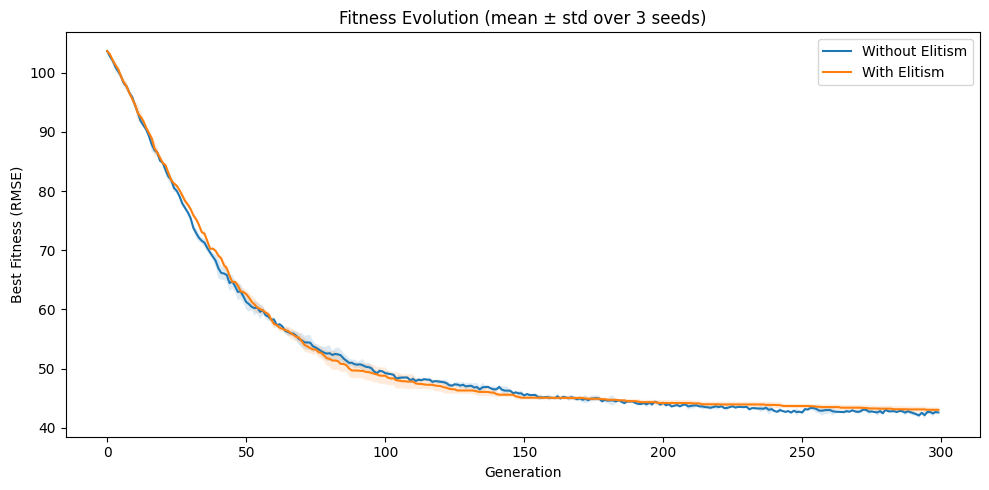

In [9]:
gens = range(len(GA_NoElite[1]))
plt.figure(figsize=(10, 5))
for result, label in [(GA_NoElite, 'Without Elitism'), (GA_Elite, 'With Elitism')]:
    plt.plot(gens, result[1], label=label)
    plt.fill_between(gens, result[1] - result[2], result[1] + result[2], alpha=0.15)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title(f'Fitness Evolution (mean ± std over {len(SEEDS)} seeds)')
plt.legend()
plt.tight_layout()
plt.savefig('output/fitness_evolution.png', bbox_inches='tight')
plt.show()

#### Diversity Evolution

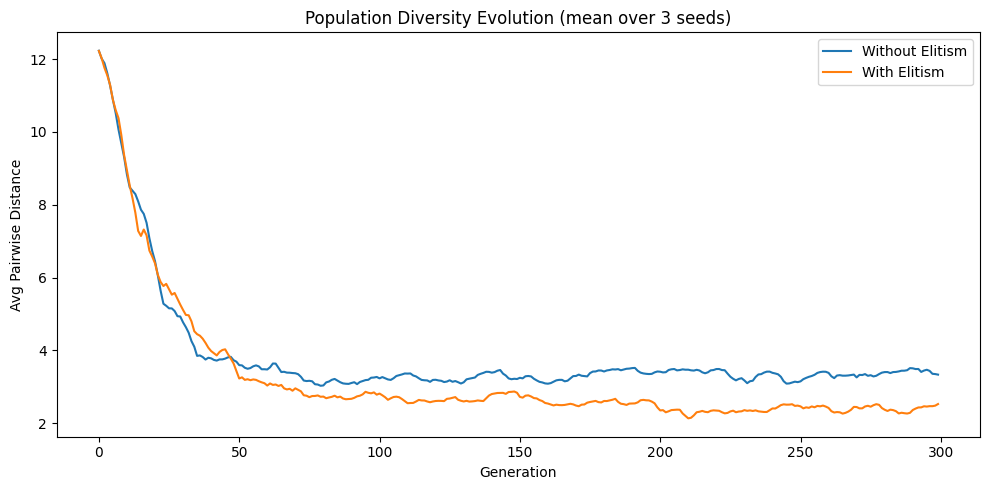

In [10]:
gens = range(len(GA_NoElite[3]))
plt.figure(figsize=(10, 5))
plt.plot(gens, GA_NoElite[3], label='Without Elitism')
plt.plot(gens, GA_Elite[3], label='With Elitism')
plt.xlabel('Generation')
plt.ylabel('Avg Pairwise Distance')
plt.title(f'Population Diversity Evolution (mean over {len(SEEDS)} seeds)')
plt.legend()
plt.tight_layout()
plt.savefig('output/diversity_evolution.png', bbox_inches='tight')
plt.show()

#### Comparison between Fitness Evolution and Diversity Evolution

Let's put both graphs side by side and let's take some conclusions

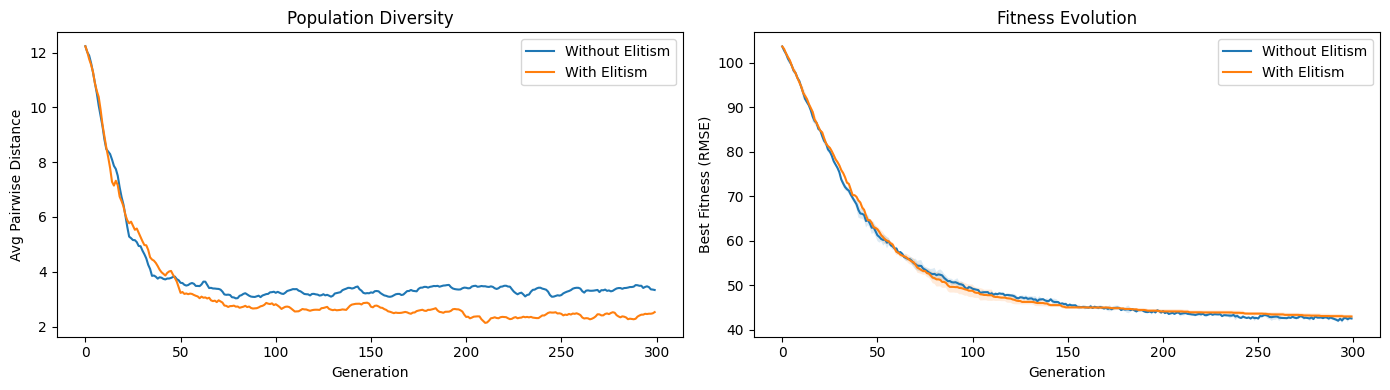

In [11]:
gens = range(len(GA_NoElite[1]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gens, GA_NoElite[3], label='Without Elitism')
axes[0].plot(gens, GA_Elite[3], label='With Elitism')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Avg Pairwise Distance')
axes[0].set_title('Population Diversity')
axes[0].legend()

for result, label in [(GA_NoElite, 'Without Elitism'), (GA_Elite, 'With Elitism')]:
    axes[1].plot(gens, result[1], label=label)
    axes[1].fill_between(gens, result[1] - result[2], result[1] + result[2], alpha=0.15)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best Fitness (RMSE)')
axes[1].set_title('Fitness Evolution')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/fitness_and_diversity.png', bbox_inches='tight')
plt.show()

As we can see the diversity falls a lot in the early generations, both with elitism and without elitism. And we also see that the fitness starts to reach a plateau in the early generations.</br>
This tell us that if we want to increase the number of generations, it might be a good ideia to apply **Fitness Sharing**.

### Final Result

Let's visualize and compare the original image and the best solution

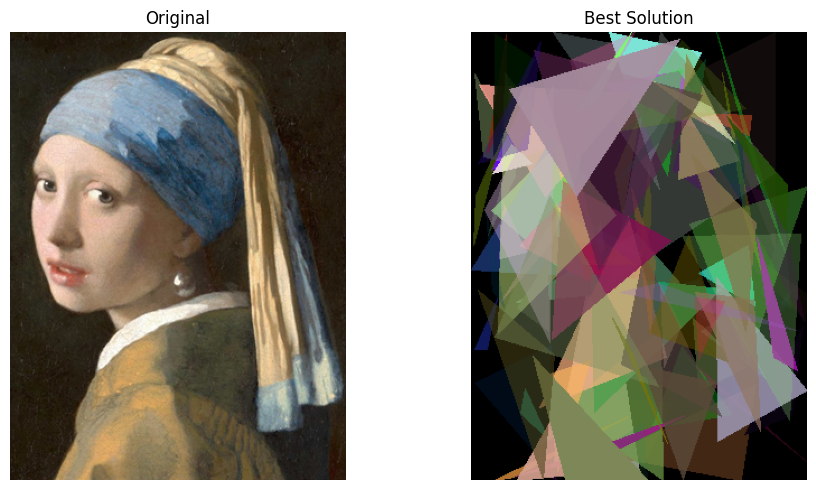

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(GA_Elite[0].render())
axes[1].set_title('Best Solution')
axes[1].axis('off')

plt.tight_layout()
fig.savefig('output/original_vs_best.png', bbox_inches='tight')
plt.show()

Let's see the evolution through the generations

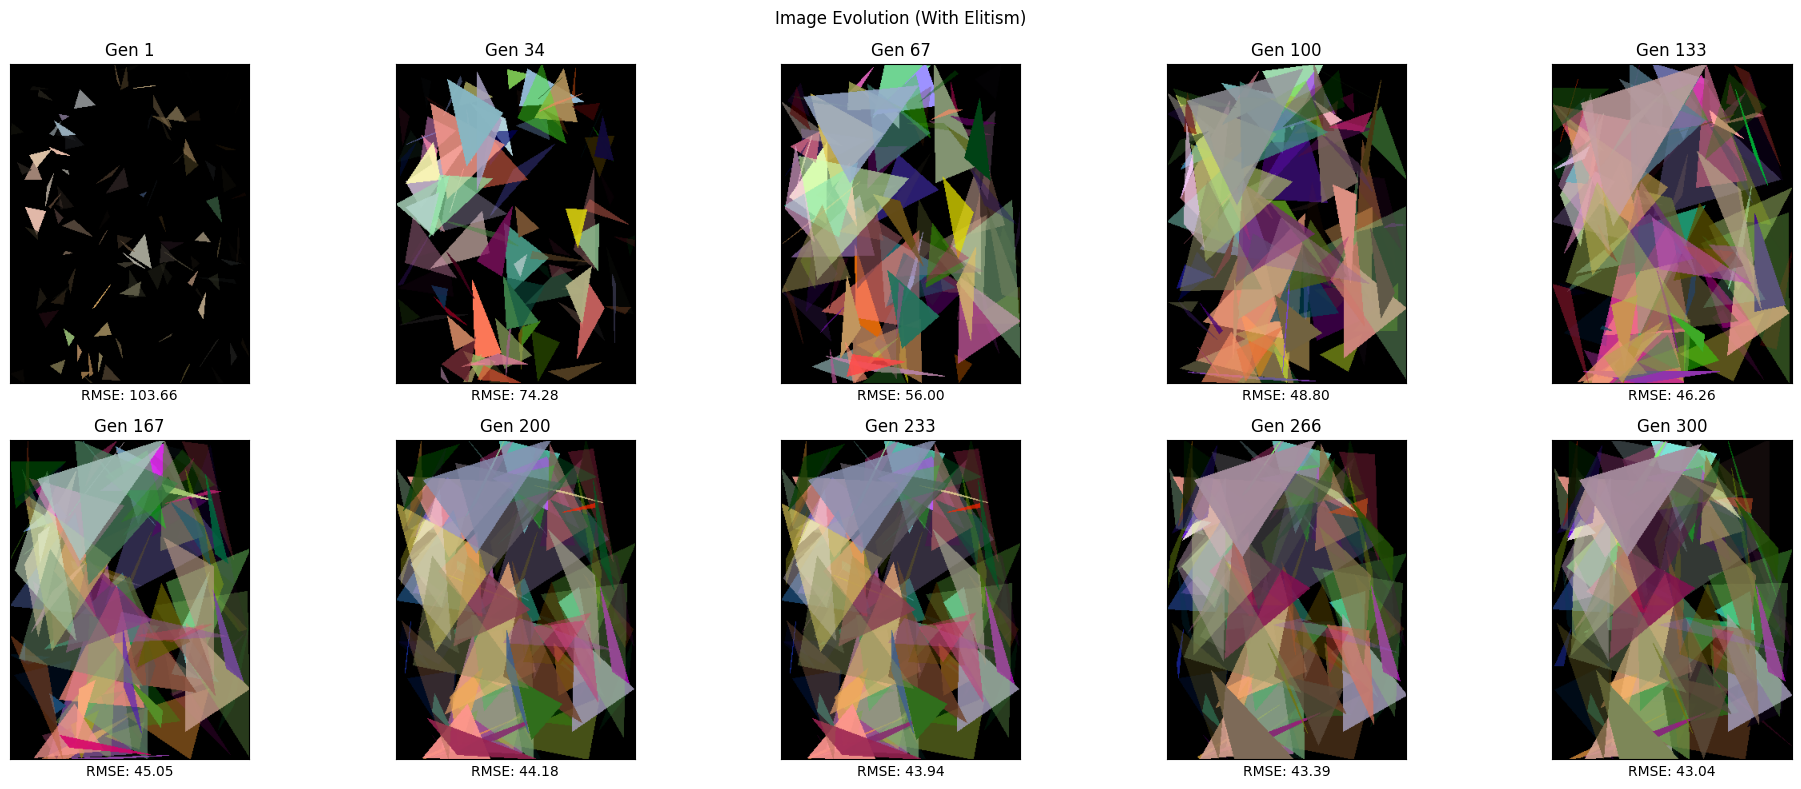

In [13]:
n_snapshots = 10
individuals = GA_Elite[4]  # best_individuals_over_gens from the best seed
indices = np.linspace(0, len(individuals) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    ax.imshow(individuals[idx].render())
    ax.set_title(f'Gen {idx + 1}')
    ax.set_xlabel(f'RMSE: {GA_Elite[1][idx]:.2f}')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Image Evolution (With Elitism)')
plt.tight_layout()
fig.savefig('output/image_evolution.png', bbox_inches='tight')
plt.show()

## 4. Ablation Study - Selection, Crossover, Mutation

### Selection - Tournament vs Rank Selection

Now we will run the GA with rank selection and with tournament selection, and let's compare the results for both.</br>
Since we saw that with elitism we had better results, we're going to keep it exactly the same, and only switch the selection method.

In [14]:
shared_kwargs = dict(
    max_generations=300,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False,
)

GA_Tournament = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'selection_algorithm': tournament_selection})
GA_Rank       = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'selection_algorithm': rank_selection})

print(f'---------- Final Results ----------')
print(f'Best solution with tournament selection has fitness: {GA_Tournament[0].fitness():.4f}')
print(f'Best solution with rank selection has fitness:      {GA_Rank[0].fitness():.4f}')

---------- Final Results ----------
Best solution with tournament selection has fitness: 42.7036
Best solution with rank selection has fitness:      42.2887


Now let's visualize the **Fitness Evolution** for both algorithms

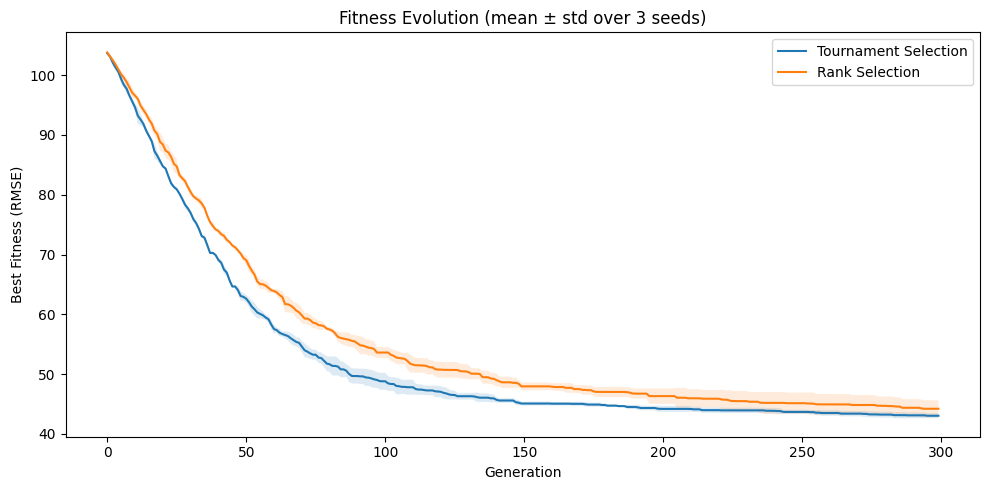

In [15]:
gens = range(len(GA_Tournament[1]))
plt.figure(figsize=(10, 5))
for result, label in [(GA_Tournament, 'Tournament Selection'), (GA_Rank, 'Rank Selection')]:
    plt.plot(gens, result[1], label=label)
    plt.fill_between(gens, result[1] - result[2], result[1] + result[2], alpha=0.15)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title(f'Fitness Evolution (mean ± std over {len(SEEDS)} seeds)')
plt.legend()
plt.tight_layout()
plt.savefig('output/tournament_vs_rank.png', bbox_inches='tight')
plt.show()

### Crossover - One-Point vs Two-Point

Now we will run the GA with one-point crossover and two-point crossover, and let's compare the results for both.</br>
Since we saw that with elitism we had better results, we're going to keep it exactly the same, and only switch the crossover method.

In [16]:
shared_kwargs = dict(
    max_generations=300,
    selection_algorithm=tournament_selection,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False,
)

GA_One_Point = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'xo_method': one_point_crossover})
GA_Two_Point = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'xo_method': two_point_crossover})

print(f'---------- Final Results ----------')
print(f'Best solution with one-point crossover has fitness: {GA_One_Point[0].fitness():.4f}')
print(f'Best solution with two-point crossover has fitness: {GA_Two_Point[0].fitness():.4f}')

---------- Final Results ----------
Best solution with one-point crossover has fitness: 42.7036
Best solution with two-point crossover has fitness: 40.9548


Now let's visualize the **Fitness Evolution** for both algorithms

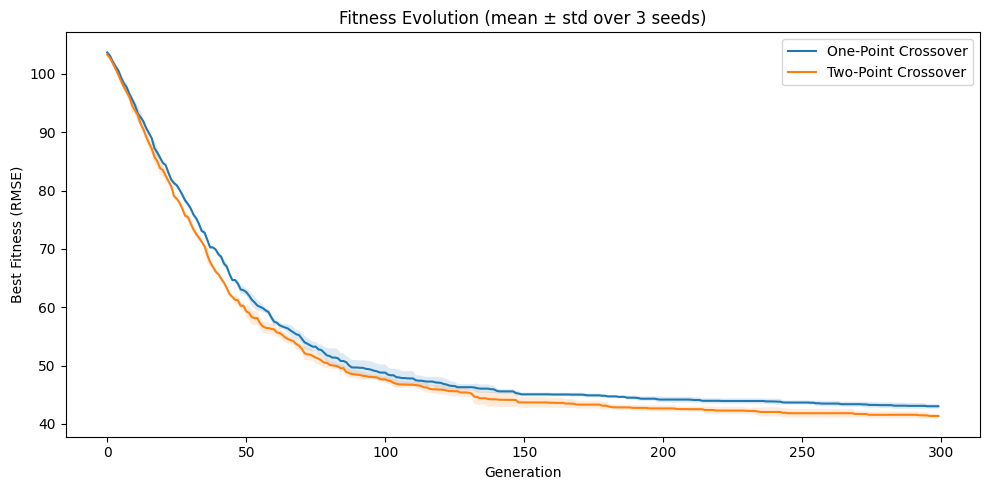

In [17]:
gens = range(len(GA_One_Point[1]))
plt.figure(figsize=(10, 5))
for result, label in [(GA_One_Point, 'One-Point Crossover'), (GA_Two_Point, 'Two-Point Crossover')]:
    plt.plot(gens, result[1], label=label)
    plt.fill_between(gens, result[1] - result[2], result[1] + result[2], alpha=0.15)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title(f'Fitness Evolution (mean ± std over {len(SEEDS)} seeds)')
plt.legend()
plt.tight_layout()
plt.savefig('output/one_point_vs_two_point.png', bbox_inches='tight')
plt.show()

### Mutation - Gaussian vs Uniform

Now we will run the GA with Gaussian mutation and Uniform Mutation, and let's compare the results for both.</br>
Since we saw that with elitism we had better results, we're going to keep it exactly the same, and only switch the mutation method.

In [18]:
shared_kwargs = dict(
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False,
)

GA_Gaussian = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'mut_method': gaussian_mutation})
GA_Uniform  = run_with_seeds(SEEDS, create_population, **{**shared_kwargs, 'mut_method': uniform_mutation})

print(f'---------- Final Results ----------')
print(f'Best solution with Gaussian mutation has fitness: {GA_Gaussian[0].fitness():.4f}')
print(f'Best solution with Uniform mutation has fitness:  {GA_Uniform[0].fitness():.4f}')

---------- Final Results ----------
Best solution with Gaussian mutation has fitness: 42.7036
Best solution with Uniform mutation has fitness:  55.6861


Now let's visualize the **Fitness Evolution** for both algorithms

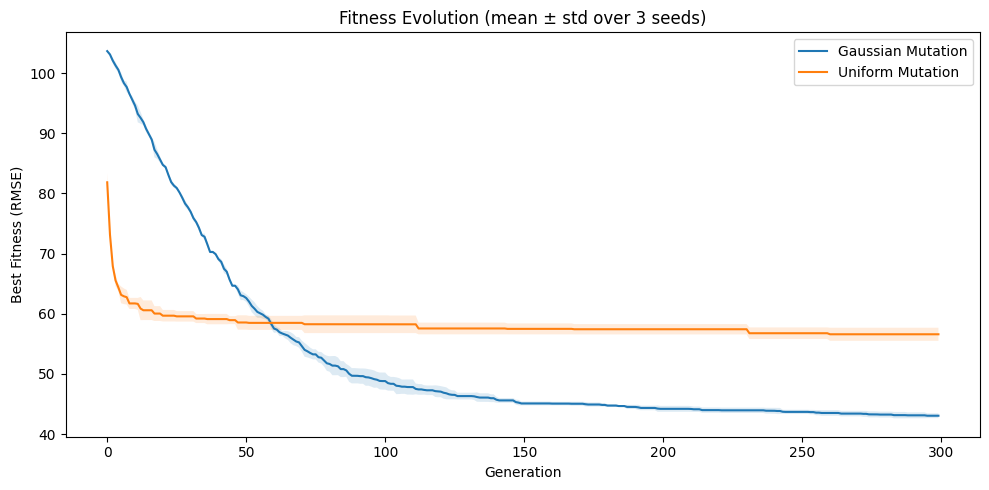

In [19]:
gens = range(len(GA_Gaussian[1]))
plt.figure(figsize=(10, 5))
for result, label in [(GA_Gaussian, 'Gaussian Mutation'), (GA_Uniform, 'Uniform Mutation')]:
    plt.plot(gens, result[1], label=label)
    plt.fill_between(gens, result[1] - result[2], result[1] + result[2], alpha=0.15)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title(f'Fitness Evolution (mean ± std over {len(SEEDS)} seeds)')
plt.legend()
plt.tight_layout()
plt.savefig('output/gaussian_vs_uniform.png', bbox_inches='tight')
plt.show()

### Conclusion

From the multi-seed comparisons (mean over 3 seeds) the following operators performed better across 300 generations:

**Selection Method**: Rank Selection performed better (RMSE 42.29 vs 42.70).  
**Crossover Method**: Two-Point Crossover performed better (RMSE 40.95 vs 42.70) — the largest single gain.  
**Mutation Method**: Gaussian Mutation performed better by a wide margin (RMSE 42.70 vs 55.69 for uniform).

**Note on Fitness Sharing**: at sigma_share=3.0, fitness sharing *degraded* performance in every configuration tested (RMSE worsened from ~40.95 to ~46.40). The ablation study was run without combining all best operators together, and sigma_share=3.0 may be too large for this problem. Both points are addressed in Section 6.

## 5. Final GA Algorithm

Now we're going to select the best methods from the ablation study, we're going to increase the maximum number of generations and we're also going to apply Fitness Sharing to see what's the final result we can get

First let's test with and without elitism

In [20]:
shared_kwargs = dict(
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    fitness_sharing=True,
    sigma_share=3.0,
    verbose=False,
)

GA_Final          = run_with_seeds(SEEDS, lambda: create_population(size=100), **{**shared_kwargs, 'elitism': True})
GA_Final_No_Elite = run_with_seeds(SEEDS, lambda: create_population(size=100), **{**shared_kwargs, 'elitism': False})

print(f'---------- Final Results ----------')
print(f'Best solution with elitism has fitness:    {GA_Final[0].fitness():.4f}')
print(f'Best solution without elitism has fitness: {GA_Final_No_Elite[0].fitness():.4f}')

---------- Final Results ----------
Best solution with elitism has fitness:    46.3968
Best solution without elitism has fitness: 47.7816


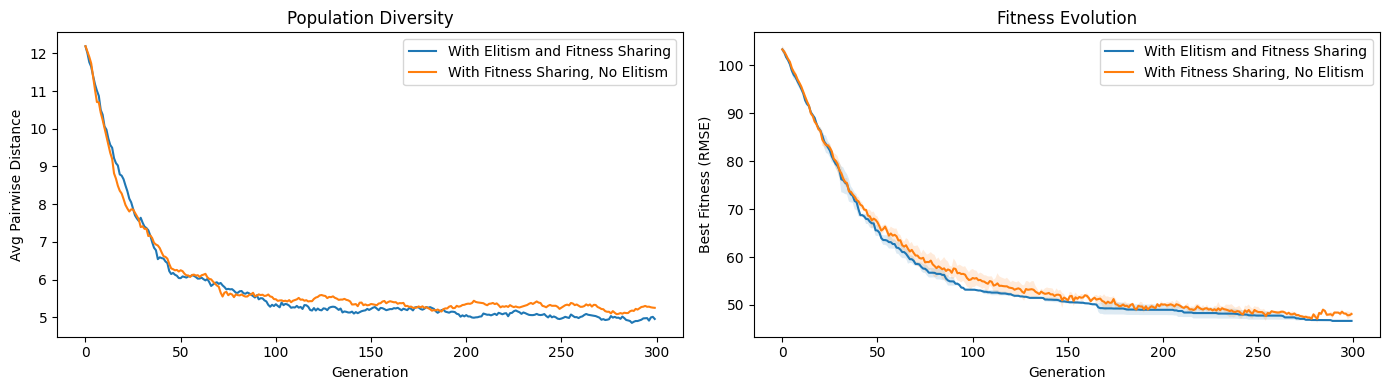

In [21]:
gens = range(len(GA_Final[1]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gens, GA_Final[3], label='With Elitism and Fitness Sharing')
axes[0].plot(gens, GA_Final_No_Elite[3], label='With Fitness Sharing, No Elitism')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Avg Pairwise Distance')
axes[0].set_title('Population Diversity')
axes[0].legend()

for result, label in [(GA_Final, 'With Elitism and Fitness Sharing'), (GA_Final_No_Elite, 'With Fitness Sharing, No Elitism')]:
    axes[1].plot(gens, result[1], label=label)
    axes[1].fill_between(gens, result[1] - result[2], result[1] + result[2], alpha=0.15)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best Fitness (RMSE)')
axes[1].set_title('Fitness Evolution')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/fitness_and_diversity_with_fitness_sharing.png', bbox_inches='tight')
plt.show()

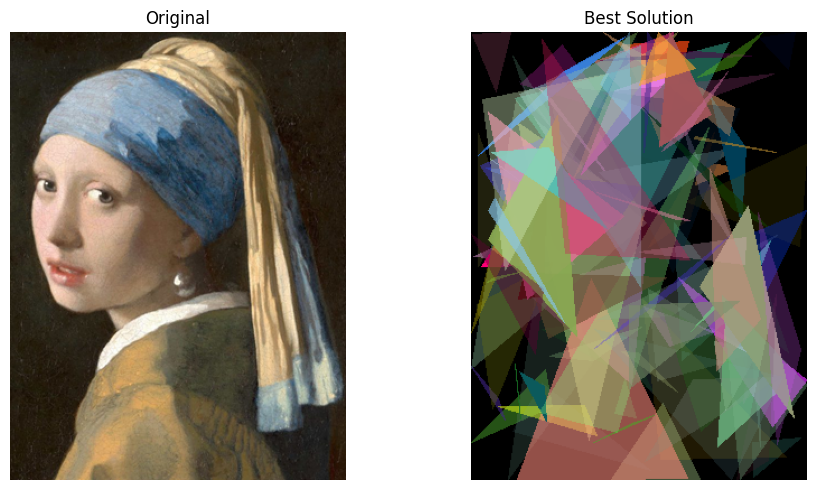

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(GA_Final[0].render())
axes[1].set_title('Best Solution')
axes[1].axis('off')

plt.tight_layout()
fig.savefig('output/original_vs_best_2.0.png', bbox_inches='tight')
plt.show()

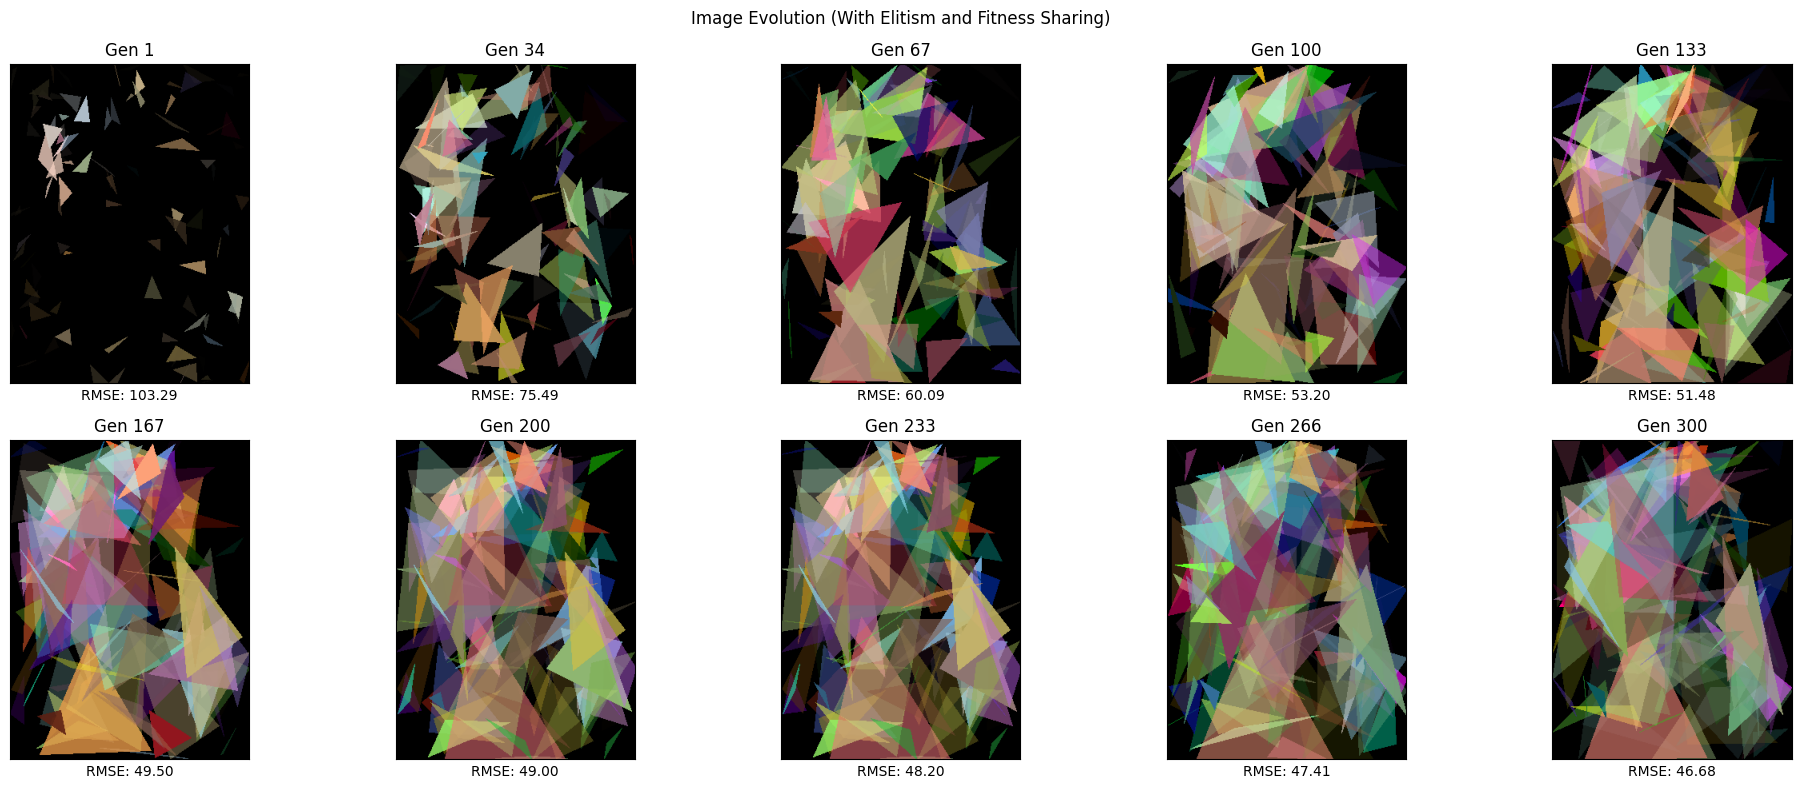

In [23]:
n_snapshots = 10
individuals = GA_Final[4]  # best_individuals_over_gens from the best seed
indices = np.linspace(0, len(individuals) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    ax.imshow(individuals[idx].render())
    ax.set_title(f'Gen {idx + 1}')
    ax.set_xlabel(f'RMSE: {GA_Final[1][idx]:.2f}')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Image Evolution (With Elitism and Fitness Sharing)')
plt.tight_layout()
fig.savefig('output/image_evolution_with_fitness_sharing.png', bbox_inches='tight')
plt.show()

In [24]:
GA = run_with_seeds(
    SEEDS,
    lambda: create_population(size=100),
    max_generations=500,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=True,
    sigma_share=3.0,
    verbose=False,
)

print(f'---------- Final Result ----------')
print(f'Best solution with elitism has fitness: {GA[0].fitness():.4f}')

---------- Final Result ----------
Best solution with elitism has fitness: 44.8644


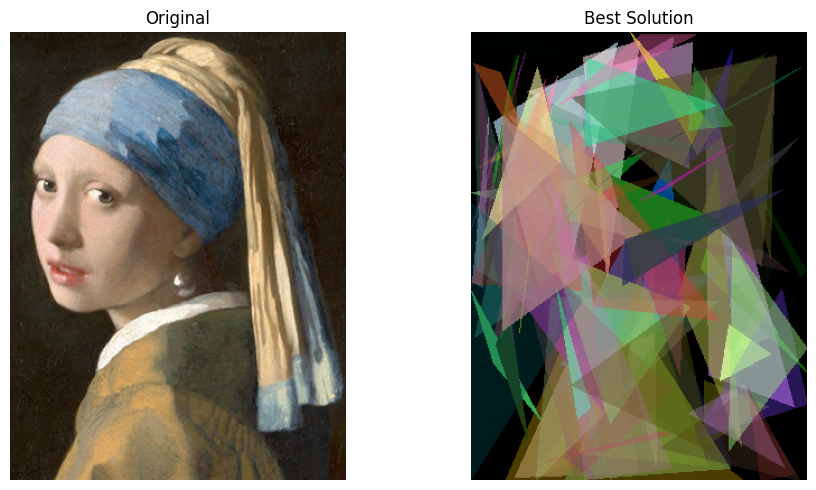

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(GA[0].render())
axes[1].set_title('Best Solution')
axes[1].axis('off')

plt.tight_layout()
fig.savefig('output/GA.png', bbox_inches='tight')
plt.show()

In [26]:
GA_NoElite_FS = run_with_seeds(
    SEEDS,
    lambda: create_population(size=100),
    max_generations=500,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False,
)

print(f'---------- Final Result ----------')
print(f'Best solution without elitism and fitness sharing has fitness: {GA_NoElite_FS[0].fitness():.4f}')

---------- Final Result ----------
Best solution without elitism and fitness sharing has fitness: 40.0934


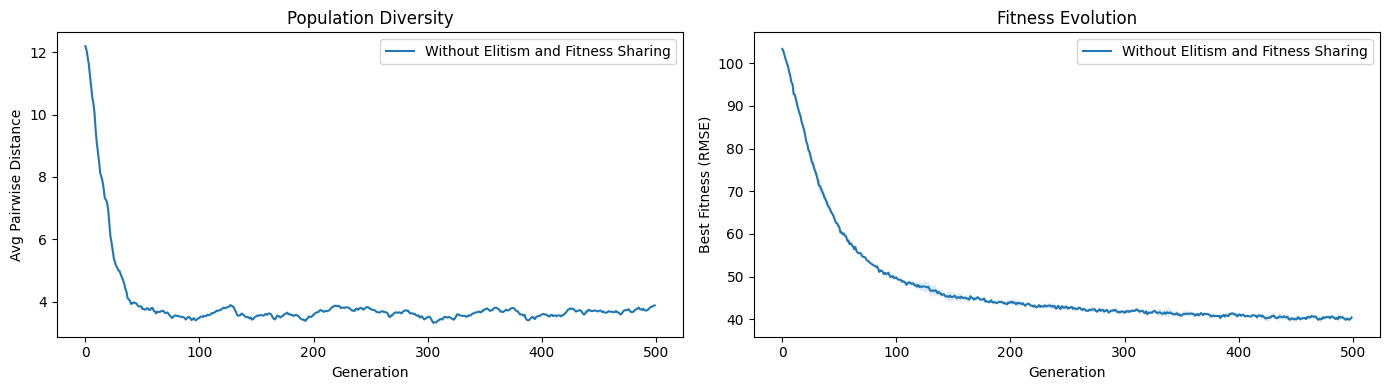

In [27]:
gens = range(len(GA_NoElite_FS[1]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gens, GA_NoElite_FS[3], label='Without Elitism and Fitness Sharing')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Avg Pairwise Distance')
axes[0].set_title('Population Diversity')
axes[0].legend()

axes[1].plot(gens, GA_NoElite_FS[1], label='Without Elitism and Fitness Sharing')
axes[1].fill_between(gens, GA_NoElite_FS[1] - GA_NoElite_FS[2], GA_NoElite_FS[1] + GA_NoElite_FS[2], alpha=0.15)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best Fitness (RMSE)')
axes[1].set_title('Fitness Evolution')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/fitness_and_diversity_no_elite_no_fs.png', bbox_inches='tight')
plt.show()

## 6. Best Configuration & Fitness Sharing Sensitivity

The ablation study varied one operator at a time from a fixed baseline. This section combines all individually-best operators and then sweeps `sigma_share` to find whether fitness sharing can help once the base configuration is strong.

### 6.1 True Best Configuration

Combine all individually-best operators: **rank selection + two-point crossover + gaussian mutation**, no elitism, no fitness sharing, run for 500 generations.

In [ ]:
GA_Best = run_with_seeds(
    SEEDS,
    lambda: create_population(size=100),
    max_generations=500,
    selection_algorithm=rank_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=False,
    verbose=False,
)

print(f'---------- Best Configuration ----------')
print(f'Rank + Two-Point + Gaussian, no elitism, 500 gen: {GA_Best[0].fitness():.4f}')
print(f'Previous best  (Tournament + Two-Point, 500 gen): {GA_NoElite_FS[0].fitness():.4f}')
print(f'Improvement: {GA_NoElite_FS[0].fitness() - GA_Best[0].fitness():.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gens_best = range(len(GA_Best[1]))
gens_prev = range(len(GA_NoElite_FS[1]))

axes[0].plot(gens_best, GA_Best[1], label='Rank + Two-Point (best config)')
axes[0].fill_between(gens_best, GA_Best[1] - GA_Best[2], GA_Best[1] + GA_Best[2], alpha=0.15)
axes[0].plot(gens_prev, GA_NoElite_FS[1], label='Tournament + Two-Point (prev best)', linestyle='--')
axes[0].fill_between(gens_prev, GA_NoElite_FS[1] - GA_NoElite_FS[2], GA_NoElite_FS[1] + GA_NoElite_FS[2], alpha=0.15)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best Fitness (RMSE)')
axes[0].set_title(f'Best Config vs Previous Best (mean ± std, {len(SEEDS)} seeds)')
axes[0].legend()

axes[1].imshow(GA_Best[0].render())
axes[1].set_title(f'Best Solution (RMSE: {GA_Best[0].fitness():.2f})')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/best_config.png', bbox_inches='tight')
plt.show()

### 6.2 Fitness Sharing Sensitivity — sigma_share sweep

Fitness sharing at `sigma_share=3.0` hurt performance in every previous test. Here we sweep `sigma_share ∈ {0.5, 1.0, 2.0, 3.0}` on the best base configuration (rank + two-point + gaussian, no elitism, 300 generations) to find whether there is a value that actually helps, and compare against the no-FS baseline at the same budget.

In [ ]:
SIGMA_VALUES = [0.5, 1.0, 2.0, 3.0]

base_kwargs = dict(
    max_generations=300,
    selection_algorithm=rank_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=True,
    verbose=False,
)

sigma_results = {}
for sigma in SIGMA_VALUES:
    print(f'Running sigma_share = {sigma}...')
    sigma_results[sigma] = run_with_seeds(
        SEEDS, lambda: create_population(size=100), **{**base_kwargs, 'sigma_share': sigma}
    )
    print(f'  → best RMSE: {sigma_results[sigma][0].fitness():.4f}')

# No-FS baseline at same budget for a fair comparison
print('\nRunning no-FS baseline (300 gen)...')
GA_Best_300 = run_with_seeds(
    SEEDS,
    lambda: create_population(size=100),
    max_generations=300,
    selection_algorithm=rank_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=False,
    verbose=False,
)
print(f'  → best RMSE (no FS): {GA_Best_300[0].fitness():.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fitness curves over generations
for sigma, result in sigma_results.items():
    g = range(len(result[1]))
    axes[0].plot(g, result[1], label=f'sigma={sigma}')
    axes[0].fill_between(g, result[1] - result[2], result[1] + result[2], alpha=0.1)
g0 = range(len(GA_Best_300[1]))
axes[0].plot(g0, GA_Best_300[1], label='No FS', linestyle='--', color='black', linewidth=1.5)
axes[0].fill_between(g0, GA_Best_300[1] - GA_Best_300[2], GA_Best_300[1] + GA_Best_300[2], alpha=0.1, color='black')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best Fitness (RMSE)')
axes[0].set_title(f'sigma_share sweep (mean ± std, {len(SEEDS)} seeds)')
axes[0].legend()

# Right: bar chart of final RMSE
labels = [f'σ={s}' for s in SIGMA_VALUES] + ['No FS']
values = [sigma_results[s][0].fitness() for s in SIGMA_VALUES] + [GA_Best_300[0].fitness()]
colors = ['steelblue'] * len(SIGMA_VALUES) + ['dimgray']
bars = axes[1].bar(labels, values, color=colors)
axes[1].set_ylabel('Best RMSE (lower is better)')
axes[1].set_title('Final RMSE by sigma_share')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.1, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('output/sigma_share_sweep.png', bbox_inches='tight')
plt.show()